# Team 7 — Code Avengers | Category 4 : Predictive Analysis


In [1]:
# ============================================================
# STEP 1: IMPORT ALL LIBRARIES
# Shared by Predictive Analysis Questions P1, P2, and P3
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# ============================================================
# SHARED DATA PATH AND DATASET LOADING
# Change ONLY DATA_DIR to your GitHub RAW/base URL.
# ============================================================

from pathlib import Path

DATA_DIR = (
    "https://raw.githubusercontent.com/"
    "kamsandhya-cyber/Team7_CodeAvengers_PythonHackathon_SEP2026/main/cleaned_data/"
)

# Read the seven cleaned datasets
demo = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_demography.csv")
labs = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_labs.csv")
cc = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
resp = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")
pp = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv")
ph = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv")
hd = pd.read_csv(DATA_DIR + "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")

# Standard names used throughout the original predictive-analysis code
demography = demo
history = ph
prescriptions = pp
cardiac = cc
responsiveness = resp
hospital = hd

tables = {
    "cardiac": cardiac,
    "demography": demography,
    "hospitalization": hospital,
    "labs": labs,
    "prescriptions": prescriptions,
    "history": history,
    "responsiveness": responsiveness
}

# Local output location for any files generated by P3.
# This does not affect dataset loading.
output_folder = Path(".")

print("All seven cleaned datasets loaded successfully!")
for name, table in tables.items():
    print(f"{name:15s}: {table.shape[0]:,} rows × {table.shape[1]} columns")

All seven cleaned datasets loaded successfully!
cardiac        : 2,008 rows × 14 columns
demography     : 2,008 rows × 7 columns
hospitalization: 2,008 rows × 21 columns
labs           : 2,008 rows × 107 columns
prescriptions  : 15,362 rows × 2 columns
history        : 2,008 rows × 17 columns
responsiveness : 2,008 rows × 6 columns


<p style="font-family: Cambria; font-size: 20px;"><b>Question 1 :  Can demographic, medical-history, medication, laboratory, cardiac, responsiveness, and hospitalization factors predict which patients are at higher risk of hospital readmission? </b></p>

<p style="font-family: Cambria; font-size: 16px;"><b> 1. Predictive Hypotheses </b>
<p>H₀ (Null Hypothesis): Demographic characteristics, comorbidity burden, medication use, laboratory markers, cardiac complications, and responsiveness measures do not significantly improve prediction of hospital readmission.</p>
<p>H₁ (Alternative Hypothesis): These patient characteristics and clinical markers do provide useful predictive information for identifying patients at greater risk of hospital readmission.</p>


<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>
Hospital readmission is an important outcome because it can reflect continuing clinical risk after discharge. This predictive analysis combines demographic, medical-history, medication, laboratory, cardiac, responsiveness, and hospitalization information to determine whether these patient characteristics can help identify individuals at higher risk of 28-day readmission. </p>

<p style="font-family: Cambria; font-size: 16px;"><b> 3. Predictive Markers from All Tables </b>

<p>Predictive markers</p>
<p>Demography - agecat, gender, bmi
<p>Patient History - cci_score, diabetes, CKD, acute renal failure
<p>Prescriptions - Medication count
<p>Labs - brain_natriuretic_peptide, creatinine_enzymatic_method, glomerular_filtration_rate, Troponin if available
<p>Cardiac Complications - lvef, NYHA class, CHF
<p>Responsiveness - gcs, consciousness
<p>Hospitalization/Discharge: readmission within 28 days </p>


Demography Shape: (2008, 7)
History Shape: (2008, 17)
Prescriptions Shape: (15362, 2)
Labs Shape: (2008, 107)
Cardiac Shape: (2008, 14)
Responsiveness Shape: (2008, 6)
Hospital Shape: (2008, 21)
Demography Unique Patients: 2008
History Unique Patients: 2008
Prescriptions Unique Patients: 2007
Labs Unique Patients: 2008
Cardiac Unique Patients: 2008
Responsiveness Unique Patients: 2008
Hospital Unique Patients: 2008
   inpatient_number  medication_count
0            722128                 7
1            723327                12
2            723617                 4
3            724385                 6
4            725509                 9
Final Modeling Dataset: (2008, 15)


,inpatient_number,agecat,gender,bmi,cci_score,medication_count,brain_natriuretic_peptide,high_sensitivity_troponin,creatinine_enzymatic_method,glomerular_filtration_rate,lvef,nyha_cardiac_function_classification,gcs,consciousness,re_admission_within_28_days
0,827040,69-79,Female,23.781,1.000,3.000,70.830,0.007,73.200,71.880,NaN,3,15,Clear,0
1,857781,69-79,Male,18.590,2.000,13.000,"1,500.170",0.094,108.300,58.570,NaN,3,15,Clear,0
2,743087,69-79,Female,19.195,0.000,3.000,361.700,0.017,62.000,85.430,NaN,3,15,Clear,0
3,866418,59-69,Male,24.221,0.000,7.000,293.950,0.010,185.100,31.510,NaN,2,15,Clear,0
4,775928,69-79,Male,22.491,2.000,8.000,"1,071.400",0.349,104.800,58.010,NaN,3,15,Clear,1


Unique Patients: 2008
Total Rows: 2008
re_admission_within_28_days
0    1868
1     140
Name: count, dtype: int64

Target Distribution:
Readmission_Target
0    1868
1     140
Name: count, dtype: int64
Predictor Shape: (2008, 13)
Target Shape: (2008,)
Training Patients: 1606
Testing Patients: 402

LOGISTIC REGRESSION
Accuracy: 0.55
Precision: 0.091
Recall: 0.607
F1 Score: 0.158
ROC-AUC: 0.601

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.55      0.69       374
           1       0.09      0.61      0.16        28

    accuracy                           0.55       402
   macro avg       0.52      0.58      0.43       402
weighted avg       0.89      0.55      0.66       402


RANDOM FOREST
Accuracy: 0.886
Precision: 0.179
Recall: 0.179
F1 Score: 0.179
ROC-AUC: 0.618


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.550,0.091,0.607,0.158,0.601
1,Random Forest,0.886,0.179,0.179,0.179,0.618


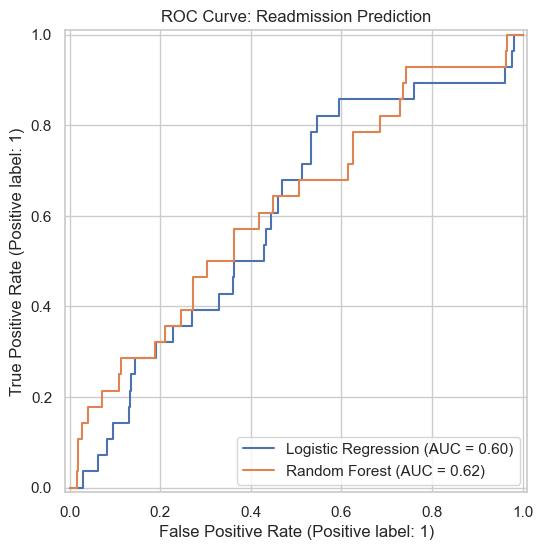


Most Important Predictive Markers


,Feature,Importance
5,numeric__creatinine_enzymatic_method,0.164
6,numeric__glomerular_filtration_rate,0.152
4,numeric__high_sensitivity_troponin,0.132
3,numeric__brain_natriuretic_peptide,0.124
0,numeric__bmi,0.110
2,numeric__medication_count,0.078
1,numeric__cci_score,0.052
7,numeric__lvef,0.045
21,categorical__nyha_cardiac_function_classificat...,0.022
19,categorical__nyha_cardiac_function_classificat...,0.018


In [4]:
# ============================================================
# PREDICTIVE ANALYSIS 1
# Predicting Hospital Readmission
# Using All Seven Healthcare Tables
# ============================================================

# ============================================================
# STEP 3: CHECK TABLE SHAPES
# ============================================================

tables = {
    "Demography": demography,
    "History": history,
    "Prescriptions": prescriptions,
    "Labs": labs,
    "Cardiac": cardiac,
    "Responsiveness": responsiveness,
    "Hospital": hospital
}

for name, table in tables.items():

    print(
        name,
        "Shape:",
        table.shape
    )


# ============================================================
# STEP 4: CHECK DUPLICATE PATIENT IDs
# ============================================================

for name, table in tables.items():

    if "inpatient_number" in table.columns:

        print(
            name,
            "Unique Patients:",
            table["inpatient_number"].nunique()
        )


# ============================================================
# STEP 5: AGGREGATE PRESCRIPTION TABLE
# ============================================================
# Prescription data can contain several rows per patient.
# Convert this into patient-level medication burden.

prescription_summary = (
    prescriptions
    .groupby("inpatient_number")
    .size()
    .reset_index(name="medication_count")
)

print(
    prescription_summary.head()
)


# ============================================================
# STEP 6: SELECT DEMOGRAPHIC VARIABLES
# ============================================================

demo_model = demography[
    [
        "inpatient_number",
        "agecat",
        "gender",
        "bmi"
    ]
].copy()


# ============================================================
# STEP 7: SELECT PATIENT HISTORY VARIABLES
# ============================================================

# Start with CCI.
# Add your exact diabetes/CKD variables here if available.

history_model = history[
    [
        "inpatient_number",
        "cci_score"
    ]
].copy()


# ============================================================
# STEP 8: SELECT LABORATORY VARIABLES
# ============================================================

labs_model = labs[
    [
        "inpatient_number",
        "brain_natriuretic_peptide",
        "high_sensitivity_troponin",
        "creatinine_enzymatic_method",
        "glomerular_filtration_rate"
    ]
].copy()


# ============================================================
# STEP 9: SELECT CARDIAC VARIABLES
# ============================================================

cardiac_model = cardiac[
    [
        "inpatient_number",
        "lvef",
        "nyha_cardiac_function_classification"
    ]
].copy()


# ============================================================
# STEP 10: SELECT RESPONSIVENESS VARIABLES
# ============================================================

response_model = responsiveness[
    [
        "inpatient_number",
        "gcs",
        "consciousness"
    ]
].copy()


# ============================================================
# STEP 11: SELECT HOSPITALIZATION TARGET
# ============================================================

hospital_model = hospital[
    [
        "inpatient_number",
        "re_admission_within_28_days"
    ]
].copy()


# ============================================================
# STEP 12: MERGE PATIENT-LEVEL TABLES
# ============================================================

df_model = (
    demo_model

    .merge(
        history_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        prescription_summary,
        on="inpatient_number",
        how="left"
    )

    .merge(
        labs_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        cardiac_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        response_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        hospital_model,
        on="inpatient_number",
        how="left"
    )
)


print(
    "Final Modeling Dataset:",
    df_model.shape
)

display(
    df_model.head()
)


# ============================================================
# STEP 13: CHECK FOR DUPLICATE PATIENTS AFTER MERGING
# ============================================================

print(
    "Unique Patients:",
    df_model["inpatient_number"].nunique()
)

print(
    "Total Rows:",
    len(df_model)
)


# ============================================================
# STEP 14: CONVERT NUMERIC VARIABLES
# ============================================================

numeric_features = [

    "bmi",
    "cci_score",
    "medication_count",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate",
    "lvef",
    "gcs"
]


for col in numeric_features:

    if col in df_model.columns:

        df_model[col] = pd.to_numeric(
            df_model[col],
            errors="coerce"
        )


# ============================================================
# STEP 15: DEFINE TARGET
# ============================================================

print(
    df_model[
        "re_admission_within_28_days"
    ].value_counts(
        dropna=False
    )
)


# IMPORTANT:
# Adjust this mapping based on how your dataset stores
# Yes/No values.

df_model["Readmission_Target"] = (

    df_model[
        "re_admission_within_28_days"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })
)


# Remove rows where target is missing

df_model = df_model[
    df_model["Readmission_Target"].notna()
].copy()


df_model["Readmission_Target"] = (
    df_model["Readmission_Target"]
    .astype(int)
)


print("\nTarget Distribution:")

print(
    df_model[
        "Readmission_Target"
    ].value_counts()
)


# ============================================================
# STEP 16: DEFINE CATEGORICAL FEATURES
# ============================================================

categorical_features = [

    "agecat",
    "gender",
    "nyha_cardiac_function_classification",
    "consciousness"
]


# ============================================================
# STEP 17: CREATE X AND y
# ============================================================

features = (
    numeric_features
    +
    categorical_features
)


X = df_model[
    features
].copy()


y = df_model[
    "Readmission_Target"
].copy()


print(
    "Predictor Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)


# ============================================================
# STEP 18: TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print(
    "Training Patients:",
    len(X_train)
)

print(
    "Testing Patients:",
    len(X_test)
)


# ============================================================
# STEP 19: NUMERIC PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            StandardScaler()
        )
    ]
)


# ============================================================
# STEP 20: CATEGORICAL PREPROCESSING
# ============================================================

categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================================
# STEP 21: COMBINE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ============================================================
# STEP 22: TRAIN LOGISTIC REGRESSION
# ============================================================

logistic_model.fit(
    X_train,
    y_train
)


# ============================================================
# STEP 23: LOGISTIC PREDICTIONS
# ============================================================

log_pred = logistic_model.predict(
    X_test
)

log_prob = logistic_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# STEP 24: LOGISTIC MODEL RESULTS
# ============================================================

print("\nLOGISTIC REGRESSION")
print("=" * 50)

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            log_pred
        ),
        3
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            log_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            log_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            log_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            log_prob
        ),
        3
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        log_pred,
        zero_division=0
    )
)


# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================

random_forest_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            RandomForestClassifier(

                n_estimators=300,

                max_depth=8,

                min_samples_leaf=5,

                class_weight="balanced",

                random_state=42
            )
        )
    ]
)


# ============================================================
# STEP 25: TRAIN RANDOM FOREST
# ============================================================

random_forest_model.fit(
    X_train,
    y_train
)


# ============================================================
# STEP 26: RANDOM FOREST PREDICTIONS
# ============================================================

rf_pred = random_forest_model.predict(
    X_test
)

rf_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# STEP 27: RANDOM FOREST RESULTS
# ============================================================

print("\nRANDOM FOREST")
print("=" * 50)

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            rf_pred
        ),
        3
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            rf_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            rf_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            rf_pred,
            zero_division=0
        ),
        3
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            rf_prob
        ),
        3
    )
)


# ============================================================
# STEP 28: COMPARE BOTH MODELS
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [

        accuracy_score(
            y_test,
            log_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        )
    ],

    "Precision": [

        precision_score(
            y_test,
            log_pred,
            zero_division=0
        ),

        precision_score(
            y_test,
            rf_pred,
            zero_division=0
        )
    ],

    "Recall": [

        recall_score(
            y_test,
            log_pred,
            zero_division=0
        ),

        recall_score(
            y_test,
            rf_pred,
            zero_division=0
        )
    ],

    "F1": [

        f1_score(
            y_test,
            log_pred,
            zero_division=0
        ),

        f1_score(
            y_test,
            rf_pred,
            zero_division=0
        )
    ],

    "ROC_AUC": [

        roc_auc_score(
            y_test,
            log_prob
        ),

        roc_auc_score(
            y_test,
            rf_prob
        )
    ]
})


display(
    model_comparison.round(3)
)


# ============================================================
# STEP 29: ROC CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)


RocCurveDisplay.from_predictions(

    y_test,
    log_prob,

    name="Logistic Regression",

    ax=ax
)


RocCurveDisplay.from_predictions(

    y_test,
    rf_prob,

    name="Random Forest",

    ax=ax
)


plt.title(
    "ROC Curve: Readmission Prediction"
)

plt.show()


# ============================================================
# STEP 30: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

fitted_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)


feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


importance = (

    random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)


feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})


feature_importance = (

    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


print(
    "\nMost Important Predictive Markers"
)


display(
    feature_importance
    .head(15)
    .round(4)
)


<p style="font-family: Cambria; font-size: 16px;"><b> Key Insight: </b>
The target variable is 28-day readmission (0 = No, 1 = Yes). The predictors come from all seven tables: demographics, CCI/history, medication burden, BNP/Troponin/Creatinine/GFR, LVEF/NYHA, and responsiveness.
For the model comparison, we have focused especially on ROC-AUC, recall, precision, and F1, not accuracy alone. In healthcare data, a model can have high accuracy simply because the outcome is uncommon. </p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 2 : Can demographic, comorbidity, laboratory, and cardiac markers predict whether a patient will show abnormal responsiveness? </b></p>

<p style="font-family: Cambria; font-size: 16px;"><b> 1. Predictive Hypotheses </b>
H₀ – Null Hypothesis: Demographic, comorbidity, cardiac, and laboratory markers do not provide useful predictive information for distinguishing normal from abnormal responsiveness.

H₁ – Alternative Hypothesis: These markers contain useful predictive information for distinguishing patients with abnormal responsiveness.</p>


<p style="font-family: Cambria; font-size: 16px;"><b> 2. Reason: </b> Responsiveness can reflect a patient's overall clinical condition. Instead of only describing which patients currently have abnormal responsiveness, predictive analysis asks whether information available in the other tables can help identify patterns associated with abnormal responsiveness.</p>


<p style="font-family: Cambria; font-size: 16px;"><b> 3. Predictive Markers from the Selected Tables </b>

Predictive markers used in the analysis:

- Demography: agecat, gender, bmi
- Patient History: cci_score
- Laboratory: selected laboratory measurements used in the model
- Cardiac Complications: selected cardiac markers used in the model
- Target: abnormal responsiveness </p>

Final Dataset Shape: (2008, 12)


,inpatient_number,agecat,gender,bmi,cci_score,brain_natriuretic_peptide,high_sensitivity_troponin,creatinine_enzymatic_method,glomerular_filtration_rate,lvef,nyha_cardiac_function_classification,consciousness
0,827040,69-79,Female,23.781,1.000,70.830,0.007,73.200,71.880,NaN,3,Clear
1,857781,69-79,Male,18.590,2.000,"1,500.170",0.094,108.300,58.570,NaN,3,Clear
2,743087,69-79,Female,19.195,0.000,361.700,0.017,62.000,85.430,NaN,3,Clear
3,866418,59-69,Male,24.221,0.000,293.950,0.010,185.100,31.510,NaN,2,Clear
4,775928,69-79,Male,22.491,2.000,"1,071.400",0.349,104.800,58.010,NaN,3,Clear


0 = Normal
1 = Abnormal
Response_Target
0    1974
1      34
Name: count, dtype: int64


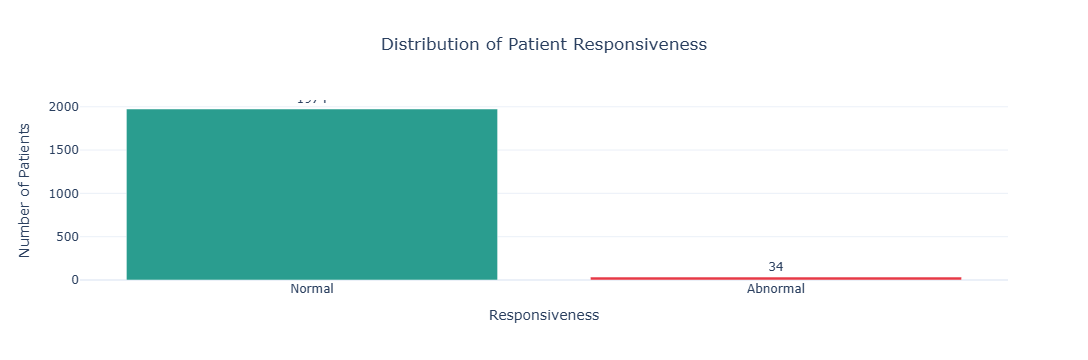

Training records: 1606
Testing records: 402


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.811,0.040,0.429,0.073,0.788
1,Random Forest,0.963,0.000,0.000,0.000,0.874


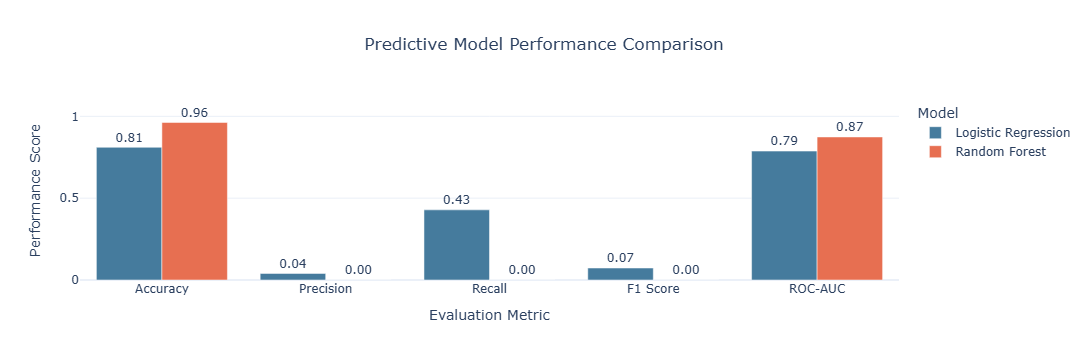

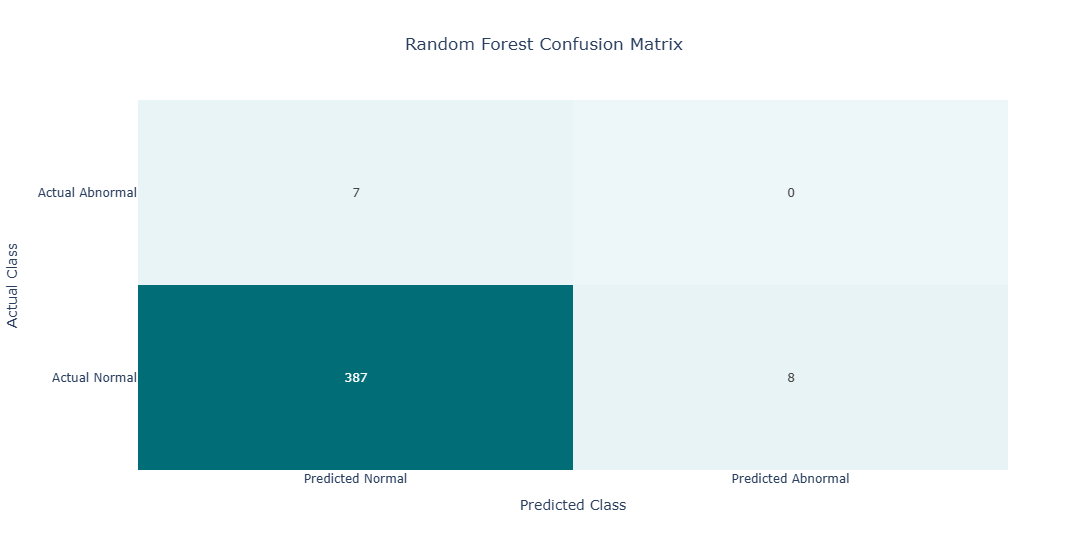

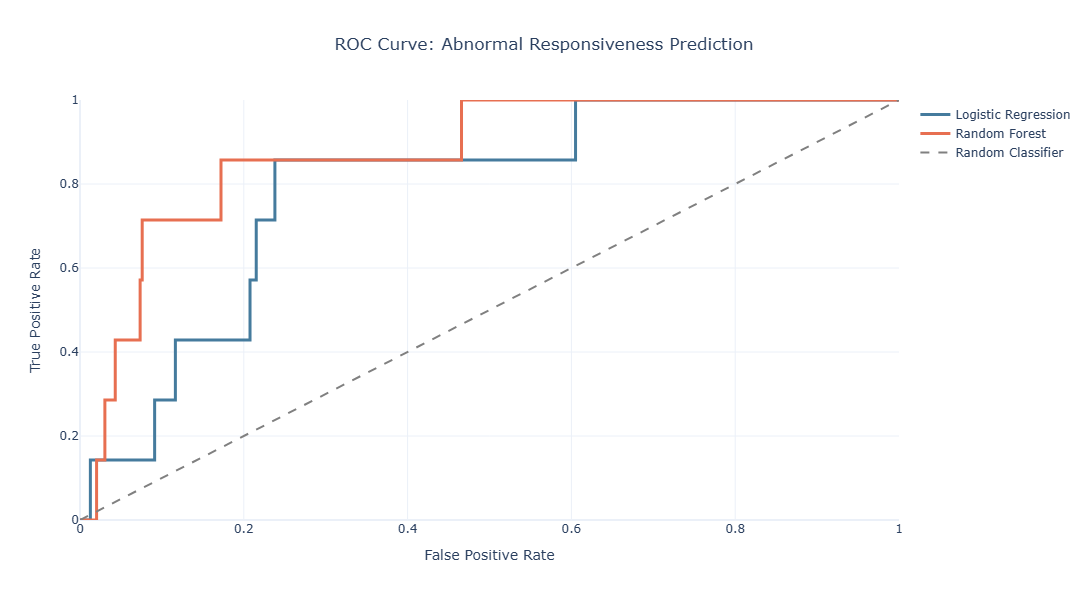

,Feature,Importance
3,high_sensitivity_troponin,0.179
19,nyha_cardiac_function_classification_4,0.173
5,glomerular_filtration_rate,0.130
4,creatinine_enzymatic_method,0.118
2,brain_natriuretic_peptide,0.090
0,bmi,0.066
18,nyha_cardiac_function_classification_3,0.064
6,lvef,0.062
1,cci_score,0.026
17,nyha_cardiac_function_classification_2,0.026


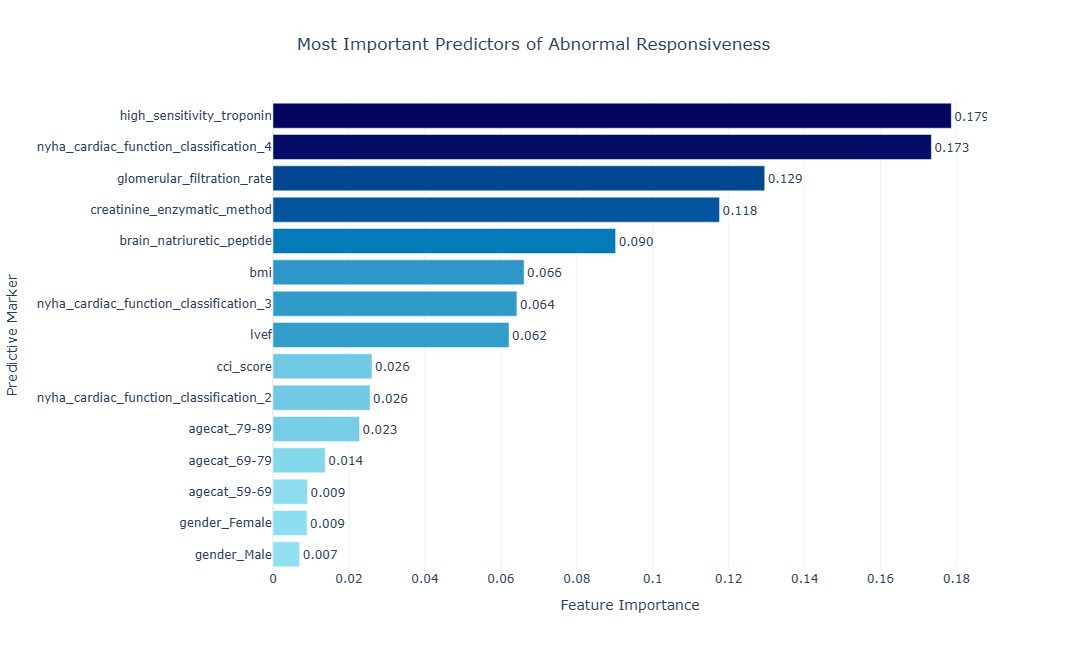


Random Forest Classification Report
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       395
    Abnormal       0.00      0.00      0.00         7

    accuracy                           0.96       402
   macro avg       0.49      0.49      0.49       402
weighted avg       0.97      0.96      0.96       402



In [5]:
# ============================================================
# PREDICTIVE ANALYSIS 2
# Predicting Abnormal Patient Responsiveness
# ============================================================

# ============================================================
# STEP 2: SELECT DEMOGRAPHIC VARIABLES
# ============================================================

demo_model = demography[
    [
        "inpatient_number",
        "agecat",
        "gender",
        "bmi"
    ]
].copy()


# ============================================================
# STEP 3: SELECT COMORBIDITY VARIABLES
# ============================================================

history_model = history[
    [
        "inpatient_number",
        "cci_score"
    ]
].copy()


# ============================================================
# STEP 4: SELECT LABORATORY VARIABLES
# ============================================================

labs_model = labs[
    [
        "inpatient_number",
        "brain_natriuretic_peptide",
        "high_sensitivity_troponin",
        "creatinine_enzymatic_method",
        "glomerular_filtration_rate"
    ]
].copy()


# ============================================================
# STEP 5: SELECT CARDIAC VARIABLES
# ============================================================

cardiac_model = cardiac[
    [
        "inpatient_number",
        "lvef",
        "nyha_cardiac_function_classification"
    ]
].copy()


# ============================================================
# STEP 6: SELECT RESPONSIVENESS TARGET
# ============================================================

response_model = responsiveness[
    [
        "inpatient_number",
        "consciousness"
    ]
].copy()


# ============================================================
# STEP 7: MERGE TABLES
# ============================================================

df_predict = (

    demo_model

    .merge(
        history_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        labs_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        cardiac_model,
        on="inpatient_number",
        how="left"
    )

    .merge(
        response_model,
        on="inpatient_number",
        how="left"
    )
)


print(
    "Final Dataset Shape:",
    df_predict.shape
)


display(
    df_predict.head()
)


# ============================================================
# STEP 8: CREATE TARGET
# ============================================================

# Clear consciousness = Normal
# Other recorded states = Abnormal

df_predict["Response_Target"] = np.where(

    df_predict["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("clear"),

    0,

    1
)


# Remove missing original consciousness records
# before modeling

df_predict = df_predict[
    df_predict["consciousness"].notna()
].copy()


# ============================================================
# STEP 9: CHECK TARGET DISTRIBUTION
# ============================================================

target_counts = (

    df_predict[
        "Response_Target"
    ]
    .value_counts()
    .sort_index()
)


print(
    "0 = Normal"
)

print(
    "1 = Abnormal"
)

print(target_counts)


# ============================================================
# CHART 1:
# RESPONSIVENESS DISTRIBUTION
# ============================================================

target_plot = (

    df_predict[
        "Response_Target"
    ]
    .map({
        0: "Normal",
        1: "Abnormal"
    })
    .value_counts()
    .reset_index()
)


target_plot.columns = [
    "Response_Status",
    "Patients"
]


fig_target = px.bar(

    target_plot,

    x="Response_Status",

    y="Patients",

    color="Response_Status",

    color_discrete_map={

        "Normal":
            "#2A9D8F",

        "Abnormal":
            "#E63946"
    },

    text="Patients",

    title=(
        "Distribution of Patient Responsiveness"
    )
)


fig_target.update_traces(

    textposition="outside"
)


fig_target.update_layout(

    title=dict(
        x=0.5
    ),

    xaxis_title=(
        "Responsiveness"
    ),

    yaxis_title=(
        "Number of Patients"
    ),

    showlegend=False,

    template="plotly_white"
)


fig_target.show()


# ============================================================
# STEP 10: DEFINE FEATURES
# ============================================================

numeric_features = [

    "bmi",

    "cci_score",

    "brain_natriuretic_peptide",

    "high_sensitivity_troponin",

    "creatinine_enzymatic_method",

    "glomerular_filtration_rate",

    "lvef"
]


categorical_features = [

    "agecat",

    "gender",

    "nyha_cardiac_function_classification"
]


# ============================================================
# STEP 11: CONVERT NUMERIC COLUMNS
# ============================================================

for col in numeric_features:

    df_predict[col] = pd.to_numeric(

        df_predict[col],

        errors="coerce"
    )


# ============================================================
# STEP 12: CREATE X AND y
# ============================================================

X = df_predict[

    numeric_features
    +
    categorical_features

].copy()


y = df_predict[
    "Response_Target"
].copy()


# ============================================================
# STEP 13: TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print(
    "Training records:",
    len(X_train)
)

print(
    "Testing records:",
    len(X_test)
)


# ============================================================
# STEP 14: NUMERIC PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            StandardScaler()
        )
    ]
)


# ============================================================
# STEP 15: CATEGORICAL PREPROCESSING
# ============================================================

categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================================
# STEP 16: COMBINE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",

            numeric_transformer,

            numeric_features
        ),

        (
            "cat",

            categorical_transformer,

            categorical_features
        )
    ]
)


# ============================================================
# STEP 17: LOGISTIC REGRESSION MODEL
# ============================================================

logistic_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            LogisticRegression(

                max_iter=2000,

                class_weight="balanced",

                random_state=42
            )
        )
    ]
)


# Train
logistic_model.fit(
    X_train,
    y_train
)


# Predictions
log_pred = logistic_model.predict(
    X_test
)


log_prob = logistic_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# STEP 18: RANDOM FOREST MODEL
# ============================================================

rf_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            RandomForestClassifier(

                n_estimators=300,

                max_depth=8,

                min_samples_leaf=5,

                class_weight="balanced",

                random_state=42
            )
        )
    ]
)


# Train
rf_model.fit(
    X_train,
    y_train
)


# Predictions
rf_pred = rf_model.predict(
    X_test
)


rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# STEP 19: MODEL PERFORMANCE FUNCTION
# ============================================================

def model_results(
    model_name,
    actual,
    prediction,
    probability
):

    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                actual,
                prediction
            ),

        "Precision":
            precision_score(
                actual,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                actual,
                prediction,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                actual,
                prediction,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                actual,
                probability
            )
    }


# ============================================================
# STEP 20: COMPARE MODELS
# ============================================================

comparison = pd.DataFrame(

    [

        model_results(

            "Logistic Regression",

            y_test,

            log_pred,

            log_prob
        ),

        model_results(

            "Random Forest",

            y_test,

            rf_pred,

            rf_prob
        )
    ]
)


display(
    comparison.round(3)
)


# ============================================================
# CHART 2:
# INTERACTIVE MODEL PERFORMANCE COMPARISON
# ============================================================

comparison_long = comparison.melt(

    id_vars="Model",

    value_vars=[

        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    var_name="Metric",

    value_name="Score"
)


fig_model = px.bar(

    comparison_long,

    x="Metric",

    y="Score",

    color="Model",

    barmode="group",

    text="Score",

    color_discrete_map={

        "Logistic Regression":
            "#457B9D",

        "Random Forest":
            "#E76F51"
    },

    title=(
        "Predictive Model Performance Comparison"
    )
)


fig_model.update_traces(

    texttemplate="%{y:.2f}",

    textposition="outside"
)


fig_model.update_layout(

    title=dict(
        x=0.5
    ),

    yaxis=dict(

        title="Performance Score",

        range=[0, 1.1]
    ),

    xaxis_title=(
        "Evaluation Metric"
    ),

    legend_title=(
        "Model"
    ),

    template="plotly_white"
)


fig_model.show()


# ============================================================
# STEP 21: RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    rf_pred
)


# ============================================================
# CHART 3:
# INTERACTIVE CONFUSION MATRIX
# ============================================================

fig_cm = go.Figure(

    data=go.Heatmap(

        z=cm,

        x=[
            "Predicted Normal",
            "Predicted Abnormal"
        ],

        y=[
            "Actual Normal",
            "Actual Abnormal"
        ],

        text=cm,

        texttemplate="%{text}",

        colorscale=[

            [0, "#EDF6F9"],

            [1, "#006D77"]
        ],

        hovertemplate=(

            "%{y}<br>"

            "%{x}<br>"

            "Patients: %{z}"

            "<extra></extra>"
        ),

        showscale=False
    )
)


fig_cm.update_layout(

    title=dict(

        text=(
            "Random Forest Confusion Matrix"
        ),

        x=0.5
    ),

    xaxis_title=(
        "Predicted Class"
    ),

    yaxis_title=(
        "Actual Class"
    ),

    width=700,

    height=550,

    template="plotly_white"
)


fig_cm.show()


# ============================================================
# STEP 22: CALCULATE ROC CURVES
# ============================================================

fpr_log, tpr_log, _ = roc_curve(

    y_test,

    log_prob
)


fpr_rf, tpr_rf, _ = roc_curve(

    y_test,

    rf_prob
)


# ============================================================
# CHART 4:
# INTERACTIVE ROC CURVE
# ============================================================

fig_roc = go.Figure()


fig_roc.add_trace(

    go.Scatter(

        x=fpr_log,

        y=tpr_log,

        mode="lines",

        name=(
            "Logistic Regression"
        ),

        line=dict(
            color="#457B9D",
            width=3
        )
    )
)


fig_roc.add_trace(

    go.Scatter(

        x=fpr_rf,

        y=tpr_rf,

        mode="lines",

        name=(
            "Random Forest"
        ),

        line=dict(
            color="#E76F51",
            width=3
        )
    )
)


# Random classifier reference line

fig_roc.add_trace(

    go.Scatter(

        x=[0, 1],

        y=[0, 1],

        mode="lines",

        name="Random Classifier",

        line=dict(

            color="gray",

            dash="dash"
        )
    )
)


fig_roc.update_layout(

    title=dict(

        text=(
            "ROC Curve: Abnormal Responsiveness Prediction"
        ),

        x=0.5
    ),

    xaxis_title=(
        "False Positive Rate"
    ),

    yaxis_title=(
        "True Positive Rate"
    ),

    xaxis=dict(
        range=[0, 1]
    ),

    yaxis=dict(
        range=[0, 1]
    ),

    width=800,

    height=600,

    template="plotly_white"
)


fig_roc.show()


# ============================================================
# STEP 23: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

fitted_preprocessor = (

    rf_model
    .named_steps[
        "preprocessor"
    ]
)


feature_names = (

    fitted_preprocessor
    .get_feature_names_out()
)


importance_values = (

    rf_model
    .named_steps[
        "classifier"
    ]
    .feature_importances_
)


feature_importance = pd.DataFrame({

    "Feature":
        feature_names,

    "Importance":
        importance_values
})


feature_importance = (

    feature_importance

    .sort_values(

        "Importance",

        ascending=False
    )

    .head(15)
)


# Clean feature names

feature_importance[
    "Feature"
] = (

    feature_importance[
        "Feature"
    ]

    .str.replace(
        "num__",
        "",
        regex=False
    )

    .str.replace(
        "cat__",
        "",
        regex=False
    )
)


display(
    feature_importance.round(4)
)


# ============================================================
# CHART 5:
# INTERACTIVE FEATURE IMPORTANCE
# ============================================================

feature_plot = (

    feature_importance
    .sort_values(
        "Importance",
        ascending=True
    )
)


fig_importance = px.bar(

    feature_plot,

    x="Importance",

    y="Feature",

    orientation="h",

    color="Importance",

    color_continuous_scale=[

        "#90E0EF",

        "#0077B6",

        "#03045E"
    ],

    text="Importance",

    title=(
        "Most Important Predictors of "
        "Abnormal Responsiveness"
    )
)


fig_importance.update_traces(

    texttemplate="%{x:.3f}",

    textposition="outside"
)


fig_importance.update_layout(

    title=dict(
        x=0.5
    ),

    xaxis_title=(
        "Feature Importance"
    ),

    yaxis_title=(
        "Predictive Marker"
    ),

    coloraxis_showscale=False,

    width=950,

    height=650,

    template="plotly_white"
)


fig_importance.show()


# ============================================================
# STEP 24: CLASSIFICATION REPORT
# ============================================================

print(
    "\nRandom Forest Classification Report"
)

print(
    classification_report(

        y_test,

        rf_pred,

        target_names=[
            "Normal",
            "Abnormal"
        ],

        zero_division=0
    )
)


<p style="font-family: Cambria; font-size: 16px;"><b> Key Insight: </b>
The P2 model evaluates whether demographic, comorbidity, laboratory, and cardiac information can help distinguish normal from abnormal responsiveness. Model performance should be interpreted using the generated evaluation metrics and visualizations rather than accuracy alone.</p>


<p style="font-family: Cambria; font-size: 20px;"><b>Question 3 :  Predicting Documented Myocardial Infarction in Hospitalized Heart-Failure Patients </b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>1. Predictive Hypotheses </b>
    
H₀ – Null Hypothesis: The selected demographic, comorbidity, laboratory, and cardiac predictors do not provide useful predictive information for distinguishing patients with documented myocardial infarction.

H₁ – Alternative Hypothesis: The selected demographic, comorbidity, laboratory, and cardiac predictors provide useful predictive information for distinguishing patients with documented myocardial infarction.
</p>

<p style="font-family: Cambria; font-size: 16px;"><b> 2. Reason:</b>
 This analysis evaluates whether clinically relevant patient characteristics available in the source tables can help distinguish hospitalized heart-failure patients with documented myocardial infarction. The workflow emphasizes patient-level joins, feature-timing checks, leakage prevention, internal validation, held-out evaluation, uncertainty, and interpretable associations rather than treating model predictions as causal conclusions.</p>


<p style="font-family: Cambria; font-size: 16px;"><b>3. Predictive Markers / Variables </b>
The P3 workflow pre-specifies clinically relevant predictors and audits their availability and missing values before modeling. Variables associated with the endpoint itself or with uncertain/post-outcome timing are excluded where specified in the original analysis to reduce target leakage.</p>


In [10]:
# ============================================================
# STEP 4: VALIDATE PATIENT KEYS AND TARGET
# ============================================================
#Reason: Medication rows are patient–drug associations, not independent patients. 
#Confirm uniqueness before joining; do not silently multiply patient records. 
#The discharge and medication tables are inspected but **excluded from prediction** 
#because they may encode events/treatments after the documented diagnosis. `responsiveness` is excluded for the same uncertain timing reason. 
#MI, CHF and peripheral vascular disease are not allowed as input predictors.
# ------------------------------------------------------------
# Validate one-row-per-patient tables
# ------------------------------------------------------------

for name, frame in {
    'Demography': demography,
    'History': history,
    'Cardiac': cardiac
}.items():

    print(
        f'{name}: '
        f'{frame["inpatient_number"].nunique():,} unique inpatient IDs'
    )

    assert frame['inpatient_number'].is_unique, \
        f'Duplicate patient key in {name}'


# ------------------------------------------------------------
# Validate prescription patient IDs
# ------------------------------------------------------------

# Prescription records may contain multiple rows per patient
# because one patient can receive multiple medications.

print(
    f'Prescriptions: '
    f'{prescriptions["inpatient_number"].nunique():,} unique inpatient IDs'
)


# ------------------------------------------------------------
# Examine cardiac complication outcomes
# ------------------------------------------------------------

for col in [
    'myocardial_infarction',
    'congestive_heart_failure',
    'peripheral_vascular_disease'
]:

    print(f'\n{col}:')

    print(
        cardiac[col]
        .value_counts(dropna=False)
        .sort_index()
    )


# ------------------------------------------------------------
# Examine heart failure classifications
# ------------------------------------------------------------

print('\nHeart failure type:')

print(
    cardiac['type_of_heart_failure']
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# Validate the predictive target
# ------------------------------------------------------------

# Confirm that all non-missing myocardial infarction values
# contain only the expected binary classes: 0 and 1.

assert cardiac['myocardial_infarction'].dropna().isin([0, 1]).all(), \
    'Unexpected values found in myocardial_infarction'


# Confirm that both target classes are present.

assert cardiac['myocardial_infarction'].dropna().nunique() == 2, \
    'Target myocardial_infarction must contain both classes 0 and 1'


# Display target distribution.

print('\nMyocardial infarction target distribution:')

print(
    cardiac['myocardial_infarction']
    .value_counts(dropna=False)
    .sort_index()
)

# ============================================================
# STEP 5: JOIN ONE ROW PER INPATIENT AND DEFINE THE OUTCOME
# ============================================================
# Preserve the full cardiac-table cohort, use the exact shared `inpatient_number` key, and explicitly report missing linked records.
# ------------------------------------------------------------
# Start with the complete cardiac cohort
# ------------------------------------------------------------

df = cardiac.copy()


# ------------------------------------------------------------
# Merge demographic information
# ------------------------------------------------------------

df = df.merge(
    demography,
    on='inpatient_number',
    how='left',
    validate='one_to_one',
    indicator='demography_match'
)


# ------------------------------------------------------------
# Merge medical history information
# ------------------------------------------------------------

df = df.merge(
    history,
    on='inpatient_number',
    how='left',
    validate='one_to_one',
    indicator='history_match'
)


# ------------------------------------------------------------
# Report demographic and history merge status
# ------------------------------------------------------------

for col in [
    'demography_match',
    'history_match'
]:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False))


# Remove merge-indicator columns after validation
df = df.drop(
    columns=[
        'demography_match',
        'history_match'
    ]
)


# ------------------------------------------------------------
# Add laboratory data if the labs dataframe is available
# ------------------------------------------------------------

if 'labs' in globals():

    # Check whether labs already has one row per inpatient.
    # If multiple lab records exist for a patient, aggregate
    # numeric laboratory measurements to the patient level.

    if not labs['inpatient_number'].is_unique:

        print(
            '\nMultiple laboratory records detected per inpatient.'
            '\nAggregating numeric laboratory measurements '
            'to one row per patient.'
        )

        numeric_lab_cols = (
            labs
            .select_dtypes(include='number')
            .columns
            .difference(['inpatient_number'])
            .tolist()
        )

        labs_patient = (
            labs[
                ['inpatient_number'] + numeric_lab_cols
            ]
            .groupby(
                'inpatient_number',
                as_index=False
            )
            .median()
        )

    else:
        labs_patient = labs.copy()


    # Merge patient-level laboratory data
    df = df.merge(
        labs_patient,
        on='inpatient_number',
        how='left',
        validate='one_to_one',
        indicator='labs_match'
    )


    print('\nlabs_match:')
    print(
        df['labs_match']
        .value_counts(dropna=False)
    )


    df = df.drop(
        columns=['labs_match']
    )

else:

    print(
        '\nLabs dataframe is not currently defined. '
        'Demography and history were merged successfully; '
        'laboratory merge was skipped.'
    )


# ------------------------------------------------------------
# Define the predictive outcome
# ------------------------------------------------------------

# Keep patients with a documented myocardial infarction outcome.
df = df[
    df['myocardial_infarction'].notna()
].copy()


# Create binary predictive target:
# 1 = myocardial infarction documented
# 0 = myocardial infarction not documented
df['documented_mi'] = (
    df['myocardial_infarction']
    .astype(int)
)


# ------------------------------------------------------------
# Validate final patient-level cohort
# ------------------------------------------------------------

assert df['inpatient_number'].is_unique, \
    'Duplicate inpatient records detected after merging.'

assert df['documented_mi'].isin([0, 1]).all(), \
    'Unexpected values detected in documented_mi.'


# ------------------------------------------------------------
# Report final cohort
# ------------------------------------------------------------

print(
    '\nFinal cohort:',
    f'{len(df):,}'
)

print(
    'MI documented:',
    f'{int(df["documented_mi"].sum()):,}'
)

print(
    'MI not documented:',
    f'{int((df["documented_mi"] == 0).sum()):,}'
)

print(
    'MI prevalence:',
    f'{df["documented_mi"].mean():.2%}'
)


# ------------------------------------------------------------
# Preview final merged dataset
# ------------------------------------------------------------

preview_cols = [
    'inpatient_number',
    'documented_mi',
    'agecat',
    'gender',
    'diabetes',
    'lvef',
    'high_sensitivity_troponin'
]

# Display only columns that are actually available
preview_cols = [
    col for col in preview_cols
    if col in df.columns
]

display(
    df[preview_cols].head()
)

# ============================================================
# STEP 6: DEFINE AND PREPARE PREDICTOR VARIABLES
# ============================================================
#Reason: Limit the primary model to interpretable covariates rather than blindly feeding all 107 lab columns into ~143 positive cases. 
#Do not use diagnoses that define the outcome, patient IDs, post-hospitalization outcomes, drugs with unknown timing, or admission/discharge dates. 
#Because labs and echo lack timestamps, the extended model is contemporaneous association/classification, not early prediction. 
#The baseline model uses demographics and documented history only; its history timing also cannot be independently confirmed.
# ------------------------------------------------------------
# Define baseline predictor candidates
# ------------------------------------------------------------

baseline_candidates = [
    'agecat',
    'gender',
    'bmi',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'chronic_obstructive_pulmonary_disease',
    'cerebrovascular_disease',
    'cci_score'
]


# ------------------------------------------------------------
# Define extended clinical predictor candidates
# ------------------------------------------------------------

extended_candidates = [
    'nyha_cardiac_function_classification',
    'killip_grade',
    'type_of_heart_failure',
    'lvef',
    'pulse',
    'systolic_blood_pressure',
    'glomerular_filtration_rate',
    'creatinine_enzymatic_method',
    'high_sensitivity_troponin',
    'brain_natriuretic_peptide',
    'hemoglobin',
    'sodium',
    'potassium',
    'albumin'
]


# ------------------------------------------------------------
# Verify that all expected predictor columns are available
# ------------------------------------------------------------

for c in baseline_candidates + extended_candidates:
    if c not in df.columns:
        raise KeyError(
            f'Expected column not in uploaded files: {c}'
        )


# ------------------------------------------------------------
# Define categorical predictors
# ------------------------------------------------------------

# Numeric categories that denote clinical severity are retained
# as categories rather than treated as interval-scale values.

categorical_candidates = [
    'agecat',
    'gender',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'chronic_obstructive_pulmonary_disease',
    'cerebrovascular_disease',
    'nyha_cardiac_function_classification',
    'killip_grade',
    'type_of_heart_failure'
]


# ------------------------------------------------------------
# Convert categorical predictors to categorical-compatible type
# ------------------------------------------------------------

for c in categorical_candidates:
    df[c] = (
        df[c]
        .astype('string')
        .astype(object)
        .where(df[c].notna(), np.nan)
    )


# ------------------------------------------------------------
# Convert remaining predictors to numeric
# ------------------------------------------------------------

numeric_candidates = (
    set(baseline_candidates + extended_candidates)
    - set(categorical_candidates)
)

for c in numeric_candidates:
    df[c] = pd.to_numeric(
        df[c],
        errors='coerce'
    )


# ------------------------------------------------------------
# Evaluate predictor missingness
# ------------------------------------------------------------

missing = pd.DataFrame({
    'missing_n':
        df[
            baseline_candidates + extended_candidates
        ].isna().sum(),

    'missing_pct':
        100 * df[
            baseline_candidates + extended_candidates
        ].isna().mean()
})


display(
    missing
    .sort_values(
        'missing_pct',
        ascending=False
    )
    .round(1)
)


# ------------------------------------------------------------
# Select predictors using the predefined missingness threshold
# ------------------------------------------------------------

# Predictors with more than 60% missing values are excluded.
# The cutoff is fixed without using outcome labels.

selected_baseline = [
    c for c in baseline_candidates
    if missing.loc[c, 'missing_pct'] <= 60
]

selected_extended = (
    selected_baseline
    + [
        c for c in extended_candidates
        if missing.loc[c, 'missing_pct'] <= 60
    ]
)


Demography: 2,008 unique inpatient IDs
History: 2,008 unique inpatient IDs
Cardiac: 2,008 unique inpatient IDs
Prescriptions: 2,007 unique inpatient IDs

myocardial_infarction:
myocardial_infarction
0    1865
1     143
Name: count, dtype: int64

congestive_heart_failure:
congestive_heart_failure
0     136
1    1872
Name: count, dtype: int64

peripheral_vascular_disease:
peripheral_vascular_disease
0    1907
1     101
Name: count, dtype: int64

Heart failure type:
type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64

Myocardial infarction target distribution:
myocardial_infarction
0    1865
1     143
Name: count, dtype: int64

demography_match:
demography_match
both          2008
left_only        0
right_only       0
Name: count, dtype: int64

history_match:
history_match
both          2008
left_only        0
right_only       0
Name: count, dtype: int64

labs_match:
labs_match
both          2008
left_only        0
right_only       0
Name: count, dtyp

,inpatient_number,documented_mi,agecat,gender,diabetes,lvef,high_sensitivity_troponin
0,848044,0,69-79,Male,1,NaN,0.194
1,821472,0,89-110,Female,0,NaN,0.024
2,866373,0,79-89,Female,0,NaN,0.030
3,793147,0,69-79,Female,1,NaN,0.103
4,739615,0,59-69,Male,0,NaN,0.007


,missing_n,missing_pct
lvef,1373,68.400
albumin,102,5.100
high_sensitivity_troponin,79,3.900
glomerular_filtration_rate,63,3.100
brain_natriuretic_peptide,35,1.700
hemoglobin,28,1.400
creatinine_enzymatic_method,23,1.100
potassium,11,0.500
sodium,11,0.500
cci_score,5,0.200


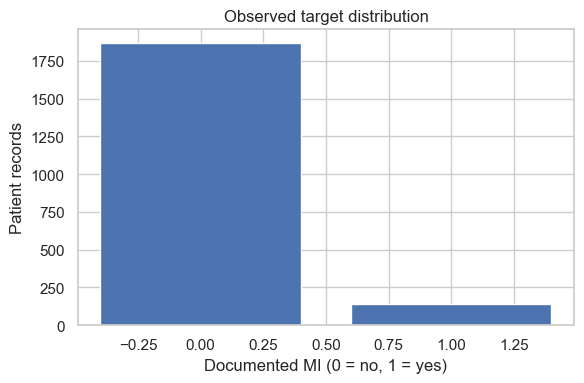

,variable,test,n_complete,p_value,observed_summary,p_fdr_bh
7,cci_score,Mann–Whitney U,2003,0.000,MI median 3; no MI median 2,0.000
9,killip_grade,Chi-square,2008,0.000,2: 1029; 1: 527; 3: 392; 4: 60,0.000
15,high_sensitivity_troponin,Mann–Whitney U,1929,0.000,MI median 0.0805; no MI median 0.053,0.000
16,brain_natriuretic_peptide,Mann–Whitney U,1973,0.000,MI median 1.19e+03; no MI median 731,0.000
8,nyha_cardiac_function_classification,Chi-square,2008,0.002,3: 1039; 4: 616; 2: 353,0.006
14,creatinine_enzymatic_method,Mann–Whitney U,1985,0.003,MI median 95.6; no MI median 86.2,0.011
1,gender,Chi-square,2008,0.004,Female: 1163; Male: 845,0.012
13,glomerular_filtration_rate,Mann–Whitney U,1945,0.005,MI median 57.6; no MI median 65.6,0.012
0,agecat,Chi-square,2008,0.006,69-79: 715; 79-89: 646; 59-69: 368; 49-59: 106...,0.014
4,moderate_to_severe_chronic_kidney_disease,Chi-square,2006,0.012,0.0: 1532; 1.0: 474,0.026


Interpretation: p<0.05 after FDR flags an exploratory association, not proof of causality.


In [19]:
# ============================================================
# STEP 7: EXPLORE TARGET DISTRIBUTION AND PREDICTOR ASSOCIATIONS
# ============================================================
#Reason: Describe actual cohort characteristics before fitting a model. 
#For categorical variables, use chi-square unless a 2×2 expected cell is <5 (then Fisher's exact). 
#For continuous variables, use Mann–Whitney U, which compares distributions, not necessarily medians. 
#Adjust exploratory p-values with Benjamini–Hochberg FDR. These are unadjusted associations, not causal effects.

# ------------------------------------------------------------
# Visualize the observed myocardial infarction target
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    [0, 1],
    df.documented_mi
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .values
)

ax.set(
    xlabel='Documented MI (0 = no, 1 = yes)',
    ylabel='Patient records',
    title='Observed target distribution'
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Perform exploratory statistical tests
# ------------------------------------------------------------

rows = []

for col in selected_extended:

    tmp = df[
        [col, 'documented_mi']
    ].dropna()


    # --------------------------------------------------------
    # Categorical predictors
    # --------------------------------------------------------

    if col in categorical_candidates:

        tab = pd.crosstab(
            tmp[col],
            tmp.documented_mi
        )

        if tab.shape[0] < 2 or tab.shape[1] < 2:
            continue

        chi, p, _, expected = chi2_contingency(tab)

        test = 'Chi-square'


        # Use Fisher's exact test for 2x2 tables
        # when expected cell counts are below 5.

        if tab.shape == (2, 2) and (expected < 5).any():

            _, p = fisher_exact(tab)

            test = 'Fisher exact'


        summary = '; '.join(
            f'{str(k)}: {int(v)}'
            for k, v in tmp[col].value_counts().items()
        )


    # --------------------------------------------------------
    # Numeric predictors
    # --------------------------------------------------------

    else:

        a = tmp.loc[
            tmp.documented_mi == 1,
            col
        ]

        z = tmp.loc[
            tmp.documented_mi == 0,
            col
        ]


        if len(a) < 2 or len(z) < 2:
            continue


        _, p = mannwhitneyu(
            a,
            z,
            alternative='two-sided'
        )

        test = 'Mann–Whitney U'


        summary = (
            f'MI median {a.median():.3g}; '
            f'no MI median {z.median():.3g}'
        )


    # --------------------------------------------------------
    # Store statistical test results
    # --------------------------------------------------------

    rows.append({
        'variable': col,
        'test': test,
        'n_complete': len(tmp),
        'p_value': p,
        'observed_summary': summary
    })


# ------------------------------------------------------------
# Create exploratory statistical test results table
# ------------------------------------------------------------

tests = pd.DataFrame(rows)


# ------------------------------------------------------------
# Apply False Discovery Rate correction
# ------------------------------------------------------------

if len(tests):

    tests['p_fdr_bh'] = multipletests(
        tests.p_value,
        method='fdr_bh'
    )[1]


    # Display results ordered by FDR-adjusted p-value

    display(
        tests
        .sort_values('p_fdr_bh')
        .round(4)
    )


    # Save exploratory statistical test results

    tests.to_csv(
        output_folder / 'PA3_exploratory_tests.csv',
        index=False
    )


# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

print(
    'Interpretation: p<0.05 after FDR flags an exploratory '
    'association, not proof of causality.'
)

In [13]:
# ============================================================
# STEP 8: CREATE TRAIN-TEST SPLIT AND DEFINE MODEL PIPELINES
# ============================================================
#Reason: Reserve 20% of patients once, stratified by the endpoint. 
#All imputation, scaling and category encoding are fit inside training folds, never on the full cohort. 
#The test set remains untouched for final evaluation. No SMOTE or artificial data generation.
# ------------------------------------------------------------
# Create stratified training and test sets
# ------------------------------------------------------------

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.20,
    stratify=df['documented_mi'],
    random_state=RANDOM_STATE
)

y_train = df.iloc[train_idx]['documented_mi']
y_test = df.iloc[test_idx]['documented_mi']


# ------------------------------------------------------------
# Report training and test sample distributions
# ------------------------------------------------------------

print(
    'Training:',
    len(train_idx),
    'positive:',
    int(y_train.sum())
)

print(
    'Test:',
    len(test_idx),
    'positive:',
    int(y_test.sum())
)


# ------------------------------------------------------------
# Define preprocessing pipeline
# ------------------------------------------------------------

def preprocess(features):

    # Separate categorical and numeric predictors
    cats = [
        c for c in features
        if c in categorical_candidates
    ]

    nums = [
        c for c in features
        if c not in categorical_candidates
    ]


    # Numeric predictors:
    # median imputation followed by standardization
    numeric_pipeline = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='median',
                add_indicator=False
            )
        ),
        (
            'scaler',
            StandardScaler()
        )
    ])


    # Categorical predictors:
    # most-frequent imputation followed by one-hot encoding
    categorical_pipeline = Pipeline([
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ])


    return ColumnTransformer(
        transformers=[
            (
                'numeric',
                numeric_pipeline,
                nums
            ),
            (
                'categorical',
                categorical_pipeline,
                cats
            )
        ],
        remainder='drop'
    )


# ------------------------------------------------------------
# Define stratified cross-validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# Define candidate predictive models
# ------------------------------------------------------------

model_specs = {

    'Prevalence baseline': (
        selected_baseline,
        DummyClassifier(
            strategy='prior'
        )
    ),

    'Baseline logistic regression': (
        selected_baseline,
        LogisticRegression(
            max_iter=3000,
            class_weight=None,
            random_state=RANDOM_STATE
        )
    ),

    'Extended logistic regression': (
        selected_extended,
        LogisticRegression(
            max_iter=3000,
            class_weight=None,
            random_state=RANDOM_STATE
        )
    ),

    'Extended random forest': (
        selected_extended,
        RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=5,
            max_features='sqrt',
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
    )
}

# ============================================================
# STEP 9: CROSS-VALIDATE MODELS AND SELECT THE FINAL MODEL
# ============================================================
#Reason: Compare prevalence-only reference, simple clinical baseline, and two extended algorithms.
#ROC-AUC measures ranking, average precision (PR-AUC) is informative for uncommon MI, and Brier score measures probability error. 
#Select the model by training CV average precision; never select it using the test set.
# ------------------------------------------------------------
# Initialize storage for cross-validation results
# ------------------------------------------------------------

cv_rows = []


# ------------------------------------------------------------
# Evaluate each candidate model using training data only
# ------------------------------------------------------------

for name, (features, estimator) in model_specs.items():

    # Build preprocessing + modeling pipeline
    pipe = Pipeline([
        (
            'prep',
            preprocess(features)
        ),
        (
            'model',
            estimator
        )
    ])


    # Perform stratified cross-validation
    result = cross_validate(
        pipe,
        df.iloc[train_idx][features],
        y_train,
        cv=cv,
        scoring={
            'roc_auc': 'roc_auc',
            'avg_precision': 'average_precision',
            'neg_brier': 'neg_brier_score'
        },
        n_jobs=1,
        error_score='raise'
    )


    # Store cross-validation performance
    cv_rows.append({

        'model':
            name,

        'cv_roc_auc_mean':
            result['test_roc_auc'].mean(),

        'cv_roc_auc_sd':
            result['test_roc_auc'].std(ddof=1),

        'cv_avg_precision_mean':
            result['test_avg_precision'].mean(),

        'cv_avg_precision_sd':
            result['test_avg_precision'].std(ddof=1),

        'cv_brier_mean':
            -result['test_neg_brier'].mean()
    })


# ------------------------------------------------------------
# Create cross-validation results table
# ------------------------------------------------------------

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        'cv_avg_precision_mean',
        ascending=False
    )
)


# ------------------------------------------------------------
# Display model performance
# ------------------------------------------------------------

display(
    cv_results.round(4)
)


# ------------------------------------------------------------
# Save cross-validation results
# ------------------------------------------------------------

cv_results.to_csv(
    output_folder / 'PA3_training_cross_validation.csv',
    index=False
)


# ------------------------------------------------------------
# Select the final predictive model
# ------------------------------------------------------------

# Exclude the prevalence baseline from final model selection.
# Candidate models are ranked using TRAINING cross-validation
# average precision.

eligible = cv_results[
    cv_results['model'] != 'Prevalence baseline'
]


chosen_name = eligible.iloc[0]['model']


# ------------------------------------------------------------
# Report selected model
# ------------------------------------------------------------

print(
    'Selected using TRAINING CV average precision:',
    chosen_name
)


print(
    '\nCross-validation and model selection '
    'completed successfully!'
)

Training: 1606 positive: 114
Test: 402 positive: 29


,model,cv_roc_auc_mean,cv_roc_auc_sd,cv_avg_precision_mean,cv_avg_precision_sd,cv_brier_mean
2,Extended logistic regression,0.907,0.033,0.502,0.140,0.050
1,Baseline logistic regression,0.902,0.031,0.433,0.086,0.052
3,Extended random forest,0.815,0.064,0.348,0.126,0.058
0,Prevalence baseline,0.500,0.000,0.071,0.001,0.066


Selected using TRAINING CV average precision: Extended logistic regression

Cross-validation and model selection completed successfully!


,model,test_roc_auc,test_avg_precision,test_brier,test_accuracy,test_balanced_accuracy,sensitivity,specificity,precision,tp,fp,tn,fn
0,Prevalence baseline,0.500,0.072,0.067,0.928,0.500,0.000,1.000,NaN,0,0,373,29
1,Baseline logistic regression,0.915,0.388,0.055,0.923,0.545,0.103,0.987,0.375,3,5,368,26
2,Extended logistic regression,0.920,0.469,0.051,0.925,0.562,0.138,0.987,0.444,4,5,368,25
3,Extended random forest,0.847,0.411,0.056,0.928,0.500,0.000,1.000,NaN,0,0,373,29


SELECTED MODEL: Extended logistic regression
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       373
           1       0.44      0.14      0.21        29

    accuracy                           0.93       402
   macro avg       0.69      0.56      0.59       402
weighted avg       0.90      0.93      0.91       402



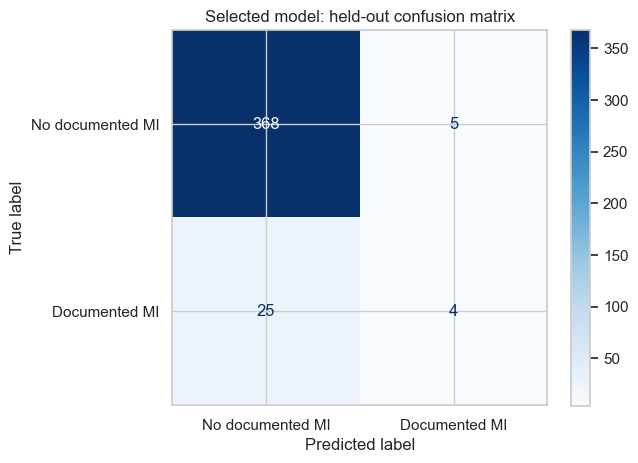


Held-out model evaluation completed successfully!


In [14]:
# ============================================================
# STEP 10: FIT MODELS AND EVALUATE ON THE HELD-OUT TEST SET
# ============================================================
#Reason: Fit each pipeline on training records only. Show all models on the same held-out records, with the training-CV-selected model identified. 
#The fixed 0.50 threshold is illustrative, not a clinically validated decision threshold. 
#Do not claim a significant model improvement merely from different point estimates.
# ------------------------------------------------------------
# Initialize storage for fitted models, probabilities,
# and held-out performance metrics
# ------------------------------------------------------------

fitted = {}
probabilities = {}
metric_rows = []


# ------------------------------------------------------------
# Fit each candidate model on the training data
# ------------------------------------------------------------

for name, (features, estimator) in model_specs.items():

    # Build preprocessing + modeling pipeline
    pipe = Pipeline([
        (
            'prep',
            preprocess(features)
        ),
        (
            'model',
            estimator
        )
    ])


    # Fit model using training data only
    pipe.fit(
        df.iloc[train_idx][features],
        y_train
    )


    # --------------------------------------------------------
    # Generate probabilities on the held-out test set
    # --------------------------------------------------------

    proba = pipe.predict_proba(
        df.iloc[test_idx][features]
    )[:, 1]


    # Convert probabilities to binary predictions
    # using the fixed 0.50 classification threshold
    pred = (
        proba >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # Calculate confusion matrix components
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred,
        labels=[0, 1]
    ).ravel()


    # Store fitted model and predicted probabilities
    fitted[name] = pipe
    probabilities[name] = proba


    # --------------------------------------------------------
    # Calculate held-out performance metrics
    # --------------------------------------------------------

    metric_rows.append({

        'model':
            name,

        'test_roc_auc':
            roc_auc_score(
                y_test,
                proba
            ),

        'test_avg_precision':
            average_precision_score(
                y_test,
                proba
            ),

        'test_brier':
            brier_score_loss(
                y_test,
                proba
            ),

        'test_accuracy':
            accuracy_score(
                y_test,
                pred
            ),

        'test_balanced_accuracy':
            balanced_accuracy_score(
                y_test,
                pred
            ),

        'sensitivity':
            tp / (tp + fn)
            if tp + fn else np.nan,

        'specificity':
            tn / (tn + fp)
            if tn + fp else np.nan,

        'precision':
            tp / (tp + fp)
            if tp + fp else np.nan,

        'tp':
            tp,

        'fp':
            fp,

        'tn':
            tn,

        'fn':
            fn
    })


# ------------------------------------------------------------
# Create held-out model performance table
# ------------------------------------------------------------

metrics = pd.DataFrame(
    metric_rows
)


# ------------------------------------------------------------
# Display held-out model performance
# ------------------------------------------------------------

display(
    metrics.round(4)
)


# ------------------------------------------------------------
# Save held-out model performance results
# ------------------------------------------------------------

metrics.to_csv(
    output_folder / 'PA3_heldout_model_metrics.csv',
    index=False
)


# ------------------------------------------------------------
# Report the model selected using training cross-validation
# ------------------------------------------------------------

print(
    'SELECTED MODEL:',
    chosen_name
)


# ------------------------------------------------------------
# Display classification report for the selected model
# ------------------------------------------------------------

selected_predictions = (
    probabilities[chosen_name] >= 0.5
).astype(int)


print(
    classification_report(
        y_test,
        selected_predictions,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Display held-out confusion matrix
# ------------------------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_predictions,
    display_labels=[
        'No documented MI',
        'Documented MI'
    ],
    cmap='Blues'
)

plt.title(
    'Selected model: held-out confusion matrix'
)

plt.tight_layout()
plt.show()


print(
    '\nHeld-out model evaluation completed successfully!'
)

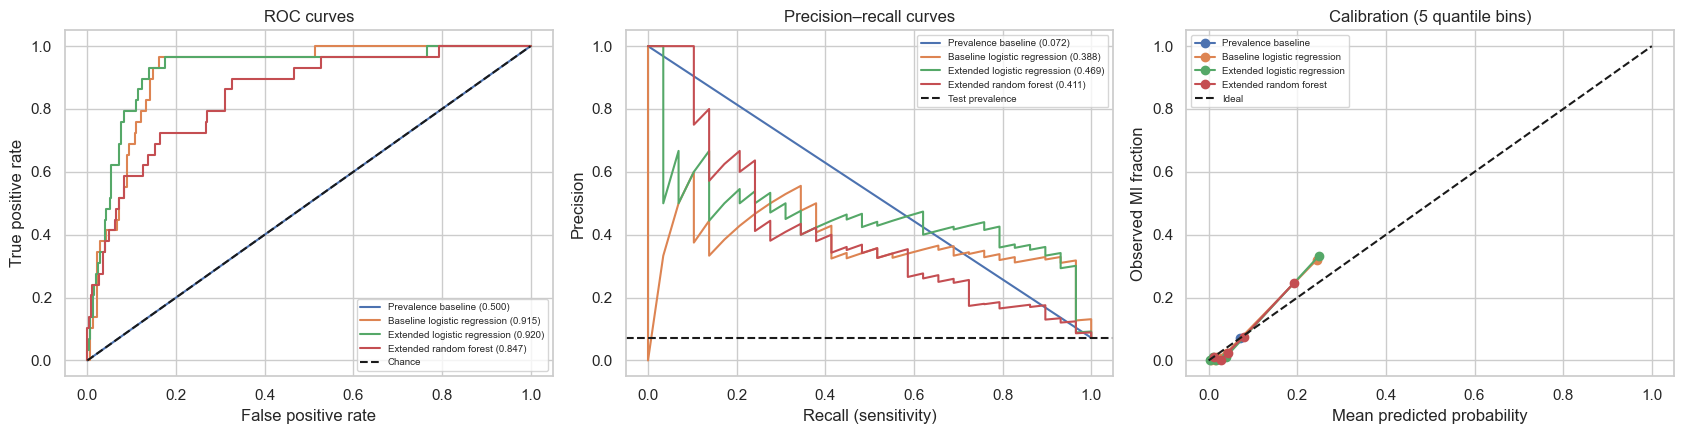


ROC, precision-recall, and calibration comparisons completed successfully!


In [15]:
# ============================================================
# STEP 11: VISUALIZE AND COMPARE MODEL PERFORMANCE
# ============================================================
#Reason: Plot full operating characteristics, not accuracy alone. The horizontal PR reference equals held-out prevalence. 
#Calibration describes whether observed MI proportions track predicted probabilities; few positives make bin-level estimates noisy.
# ------------------------------------------------------------
# Create comparison figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5)
)


# ------------------------------------------------------------
# Generate performance curves for each model
# ------------------------------------------------------------

for name, proba in probabilities.items():

    # --------------------------------------------------------
    # ROC curve
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_test,
        proba
    )

    axes[0].plot(
        fpr,
        tpr,
        label=(
            f'{name} '
            f'({roc_auc_score(y_test, proba):.3f})'
        )
    )


    # --------------------------------------------------------
    # Precision-recall curve
    # --------------------------------------------------------

    precision, recall, _ = precision_recall_curve(
        y_test,
        proba
    )

    axes[1].plot(
        recall,
        precision,
        label=(
            f'{name} '
            f'({average_precision_score(y_test, proba):.3f})'
        )
    )


    # --------------------------------------------------------
    # Calibration curve
    # --------------------------------------------------------

    obs, est = calibration_curve(
        y_test,
        proba,
        n_bins=5,
        strategy='quantile'
    )

    axes[2].plot(
        est,
        obs,
        marker='o',
        label=name
    )


# ------------------------------------------------------------
# Add ROC reference line
# ------------------------------------------------------------

axes[0].plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Chance'
)


# ------------------------------------------------------------
# Add precision-recall prevalence reference
# ------------------------------------------------------------

axes[1].axhline(
    y_test.mean(),
    color='k',
    ls='--',
    label='Test prevalence'
)


# ------------------------------------------------------------
# Add ideal calibration reference line
# ------------------------------------------------------------

axes[2].plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Ideal'
)


# ------------------------------------------------------------
# Format comparison charts
# ------------------------------------------------------------

for ax, title, xlab, ylab in zip(

    axes,

    [
        'ROC curves',
        'Precision–recall curves',
        'Calibration (5 quantile bins)'
    ],

    [
        'False positive rate',
        'Recall (sensitivity)',
        'Mean predicted probability'
    ],

    [
        'True positive rate',
        'Precision',
        'Observed MI fraction'
    ]
):

    ax.set(
        title=title,
        xlabel=xlab,
        ylabel=ylab
    )

    ax.legend(
        fontsize=7
    )


# ------------------------------------------------------------
# Save and display model comparison figure
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    output_folder / 'PA3_model_comparison.png',
    dpi=170,
    bbox_inches='tight'
)

plt.show()


print(
    '\nROC, precision-recall, and calibration '
    'comparisons completed successfully!'
)

In [16]:
# ============================================================
# STEP 12: ESTIMATE UNCERTAINTY AND PERFORM PERMUTATION TESTING
# ============================================================
#Reason: Patient-level stratified bootstrap estimates uncertainty in held-out ROC-AUC and average precision without inventing patients. 
#The empirical label-permutation check asks whether the fixed model's ROC-AUC is unusually high under random correspondence between predictions and labels; it does not re-run model selection and is exploratory. 
#Confidence intervals quantify sampling uncertainty, not external validity.
# ------------------------------------------------------------
# Initialize reproducible random number generator
# ------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_STATE
)


# ------------------------------------------------------------
# Retrieve selected model probabilities and test outcomes
# ------------------------------------------------------------

proba = probabilities[
    chosen_name
]

y_array = y_test.to_numpy()


# ------------------------------------------------------------
# Identify positive and negative test cases
# ------------------------------------------------------------

pos = np.flatnonzero(
    y_array == 1
)

neg = np.flatnonzero(
    y_array == 0
)


# ------------------------------------------------------------
# Initialize bootstrap result storage
# ------------------------------------------------------------

boot_roc = []
boot_ap = []


# ------------------------------------------------------------
# Perform stratified bootstrap resampling
# ------------------------------------------------------------

# Positive and negative cases are resampled separately
# to preserve the class structure of the held-out test set.

for _ in range(1000):

    sample = np.r_[

        rng.choice(
            pos,
            size=len(pos),
            replace=True
        ),

        rng.choice(
            neg,
            size=len(neg),
            replace=True
        )
    ]


    # Calculate ROC-AUC for bootstrap sample
    boot_roc.append(
        roc_auc_score(
            y_array[sample],
            proba[sample]
        )
    )


    # Calculate average precision for bootstrap sample
    boot_ap.append(
        average_precision_score(
            y_array[sample],
            proba[sample]
        )
    )


# ------------------------------------------------------------
# Report ROC-AUC with 95% bootstrap confidence interval
# ------------------------------------------------------------

print(
    'Selected held-out ROC-AUC:',
    round(
        roc_auc_score(
            y_array,
            proba
        ),
        4
    ),
    '| 95% stratified bootstrap percentile CI:',
    np.round(
        np.quantile(
            boot_roc,
            [0.025, 0.975]
        ),
        4
    )
)


# ------------------------------------------------------------
# Report average precision with 95% bootstrap confidence interval
# ------------------------------------------------------------

print(
    'Selected held-out average precision:',
    round(
        average_precision_score(
            y_array,
            proba
        ),
        4
    ),
    '| 95% stratified bootstrap percentile CI:',
    np.round(
        np.quantile(
            boot_ap,
            [0.025, 0.975]
        ),
        4
    )
)


# ------------------------------------------------------------
# Generate permutation-based null distribution
# ------------------------------------------------------------

null_auc = np.array([

    roc_auc_score(
        rng.permutation(y_array),
        proba
    )

    for _ in range(1000)
])


# ------------------------------------------------------------
# Calculate observed held-out ROC-AUC
# ------------------------------------------------------------

observed_auc = roc_auc_score(
    y_array,
    proba
)


# ------------------------------------------------------------
# Calculate exploratory two-sided permutation p-value
# ------------------------------------------------------------

p_perm = (
    1
    + np.sum(
        np.abs(null_auc - 0.5)
        >= abs(observed_auc - 0.5)
    )
) / (
    len(null_auc) + 1
)


# ------------------------------------------------------------
# Report permutation test result
# ------------------------------------------------------------

print(
    'Exploratory two-sided label-permutation p-value '
    'for fixed held-out predictions:',
    round(
        p_perm,
        4
    )
)


# ------------------------------------------------------------
# State permutation test hypotheses
# ------------------------------------------------------------

print(
    'Null: held-out labels and fixed predictions are '
    'exchangeable; alternative: they are associated.'
)


print(
    '\nBootstrap confidence intervals and exploratory '
    'permutation testing completed successfully!'
)

Selected held-out ROC-AUC: 0.9203 | 95% stratified bootstrap percentile CI: [0.8634 0.9643]
Selected held-out average precision: 0.4693 | 95% stratified bootstrap percentile CI: [0.3527 0.6619]
Exploratory two-sided label-permutation p-value for fixed held-out predictions: 0.001
Null: held-out labels and fixed predictions are exchangeable; alternative: they are associated.

Bootstrap confidence intervals and exploratory permutation testing completed successfully!


Exploratory two-sided label-permutation p-value for fixed held-out predictions: 0.001
Null: held-out labels and fixed predictions are exchangeable; alternative: they are associated.


,variable,mean_auc_drop,sd_auc_drop
7,cci_score,0.455,0.045
4,moderate_to_severe_chronic_kidney_disease,0.061,0.017
5,chronic_obstructive_pulmonary_disease,0.056,0.031
3,diabetes,0.052,0.014
6,cerebrovascular_disease,0.026,0.020
0,agecat,0.009,0.006
15,high_sensitivity_troponin,0.007,0.002
18,sodium,0.004,0.002
16,brain_natriuretic_peptide,0.002,0.003
10,type_of_heart_failure,0.001,0.003


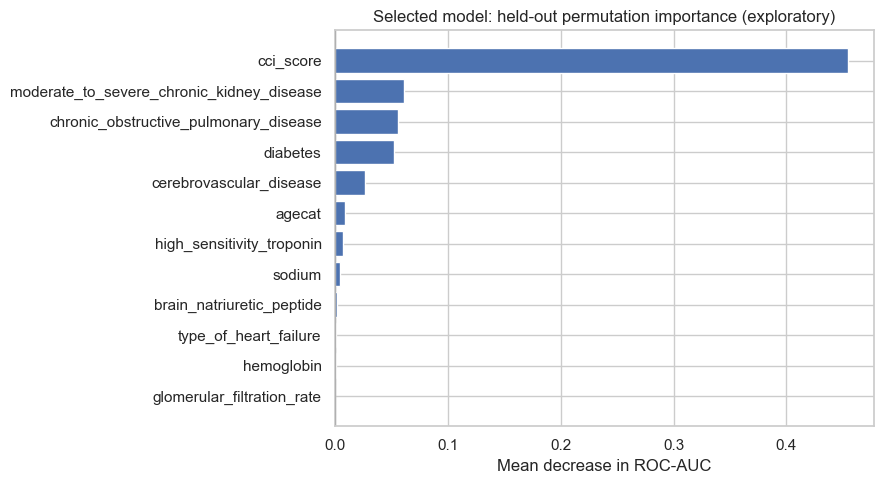


Held-out permutation importance analysis completed successfully!


In [21]:
# ============================================================
# STEP 13: EVALUATE PERMUTATION FEATURE IMPORTANCE
# ============================================================
#Reason: Held-out permutation importance measures how much test ROC-AUC drops when one input is shuffled; 
#correlated variables can share importance. For transparent adjusted inference, 
#fit a separate exploratory logistic model on training data only using a small,
#prespecified set of available covariates, and report odds ratios with confidence intervals. 
#The inference model is not the selected prediction model; its p-values do not validate predictive accuracy.
# ------------------------------------------------------------
# Retrieve predictors used by the selected model
# ------------------------------------------------------------

chosen_features = model_specs[
    chosen_name
][0]


# ------------------------------------------------------------
# Calculate held-out permutation importance
# ------------------------------------------------------------

# Each predictor is randomly permuted while the other predictors
# remain unchanged. The resulting decrease in ROC-AUC indicates
# how much the selected model relies on that predictor.

perm = permutation_importance(
    fitted[chosen_name],
    df.iloc[test_idx][chosen_features],
    y_test,
    scoring='roc_auc',
    n_repeats=12,
    random_state=RANDOM_STATE,
    n_jobs=1
)


# ------------------------------------------------------------
# Create permutation importance results table
# ------------------------------------------------------------

importance = pd.DataFrame({

    'variable':
        chosen_features,

    'mean_auc_drop':
        perm.importances_mean,

    'sd_auc_drop':
        perm.importances_std

}).sort_values(
    'mean_auc_drop',
    ascending=False
)


# ------------------------------------------------------------
# Display permutation importance results
# ------------------------------------------------------------

display(
    importance.round(4)
)


# ------------------------------------------------------------
# Save permutation importance results
# ------------------------------------------------------------

importance.to_csv(
    output_folder / 'PA3_permutation_importance.csv',
    index=False
)


# ------------------------------------------------------------
# Visualize the top 12 predictors
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.barh(
    importance.head(12)['variable'][::-1],
    importance.head(12)['mean_auc_drop'][::-1]
)


# Add reference line at zero importance
plt.axvline(
    0,
    color='black',
    lw=0.8
)


# ------------------------------------------------------------
# Format permutation importance chart
# ------------------------------------------------------------

plt.title(
    'Selected model: held-out permutation importance (exploratory)'
)

plt.xlabel(
    'Mean decrease in ROC-AUC'
)

plt.tight_layout()
plt.show()


print(
    '\nHeld-out permutation importance analysis '
    'completed successfully!'
)

In [20]:
# ============================================================
# STEP 14: PERFORM EXPLORATORY ADJUSTED LOGISTIC REGRESSION
# ============================================================
#Reason: Export observed labels and estimated probabilities for reproducibility. 
#Never describe predicted probability as an established future risk. 
#The following conclusion prints actual computed numbers rather than inserting imagined findings.


# ------------------------------------------------------------
# Define candidate variables for adjusted inference
# ------------------------------------------------------------

inference_candidates = [
    'bmi',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'cci_score',
    'lvef',
    'glomerular_filtration_rate',
    'high_sensitivity_troponin'
]


# ------------------------------------------------------------
# Retain available predictors from the extended feature set
# ------------------------------------------------------------

inference_vars = [
    c for c in inference_candidates
    if c in selected_extended
]


# ------------------------------------------------------------
# Create complete-case training dataset
# ------------------------------------------------------------

# Keep complete-case inferential analysis separate from
# the imputed predictive modeling pipeline.

infer = (
    df.iloc[train_idx][
        inference_vars + ['documented_mi']
    ]
    .dropna()
    .copy()
)


# ------------------------------------------------------------
# Report complete-case sample size
# ------------------------------------------------------------

print(
    'Complete-case training records for exploratory adjusted model:',
    len(infer),
    '| positive cases:',
    int(infer.documented_mi.sum())
)


# ------------------------------------------------------------
# Verify sufficient records and positive cases
# ------------------------------------------------------------

if (
    len(infer) >= 100
    and infer.documented_mi.sum() >= 20
):

    # --------------------------------------------------------
    # Construct inference design matrix
    # --------------------------------------------------------

    design = pd.DataFrame(
        index=infer.index
    )


    for c in inference_vars:

        if c in categorical_candidates:

            design[c] = pd.to_numeric(
                infer[c],
                errors='coerce'
            )

        else:

            design[c] = infer[c]


    # Remove records that cannot be represented numerically
    design = design.dropna()


    # --------------------------------------------------------
    # Remove predictors without variation
    # --------------------------------------------------------

    valid = [
        c for c in design
        if design[c].nunique() > 1
    ]

    design = design[
        valid
    ]


    # --------------------------------------------------------
    # Standardize continuous predictors
    # --------------------------------------------------------

    # Continuous variables are scaled using the training
    # complete-case standard deviation.
    # Their odds ratios therefore represent a 1-SD increase.

    for c in design:

        if c not in categorical_candidates:

            sd = design[c].std()

            if sd > 0:

                design[c] = (
                    design[c] - design[c].mean()
                ) / sd


    # --------------------------------------------------------
    # Verify final design matrix and positive-case count
    # --------------------------------------------------------

    if (
        len(design.columns) > 0
        and infer.loc[
            design.index,
            'documented_mi'
        ].sum() >= 20
    ):

        try:

            # ------------------------------------------------
            # Fit adjusted logistic regression model
            # ------------------------------------------------

            fit = sm.Logit(
                infer.loc[
                    design.index,
                    'documented_mi'
                ],
                sm.add_constant(design)
            ).fit(
                disp=False,
                maxiter=200
            )


            # ------------------------------------------------
            # Extract confidence intervals
            # ------------------------------------------------

            conf = fit.conf_int()


            # ------------------------------------------------
            # Calculate adjusted odds ratios
            # ------------------------------------------------

            odds = pd.DataFrame({

                'term':
                    fit.params.index,

                'odds_ratio':
                    np.exp(
                        fit.params.values
                    ),

                'ci_low':
                    np.exp(
                        conf.iloc[:, 0].values
                    ),

                'ci_high':
                    np.exp(
                        conf.iloc[:, 1].values
                    ),

                'p_value':
                    fit.pvalues.values
            })


            # ------------------------------------------------
            # Display adjusted odds ratios
            # ------------------------------------------------

            display(
                odds.round(4)
            )


            # ------------------------------------------------
            # Save adjusted odds ratio results
            # ------------------------------------------------

            odds.to_csv(
                output_folder
                / 'PA3_exploratory_adjusted_odds_ratios.csv',
                index=False
            )


            # ------------------------------------------------
            # Interpretation guidance
            # ------------------------------------------------

            print(
                'Numeric terms: OR per 1 SD; '
                'binary terms: OR for 1 vs 0. '
                'Observational associations only.'
            )


        except Exception as exc:

            print(
                'Adjusted inference unstable or failed; '
                'not interpreted:',
                str(exc)
            )


# ------------------------------------------------------------
# Handle insufficient complete-case data
# ------------------------------------------------------------

else:

    print(
        'Insufficient complete cases/positive cases for '
        'reliable exploratory adjusted model; skipped.'
    )

Complete-case training records for exploratory adjusted model: 1499 | positive cases: 106


,term,odds_ratio,ci_low,ci_high,p_value
0,const,0.075,0.056,0.102,0.000
1,bmi,1.006,0.758,1.336,0.966
2,diabetes,0.303,0.174,0.526,0.000
3,moderate_to_severe_chronic_kidney_disease,0.190,0.102,0.353,0.000
4,cci_score,4.924,3.733,6.495,0.000
5,glomerular_filtration_rate,0.755,0.568,1.003,0.052
6,high_sensitivity_troponin,1.339,1.149,1.560,0.000


Numeric terms: OR per 1 SD; binary terms: OR for 1 vs 0. Observational associations only.


In [18]:
# ============================================================
# STEP 15: SAVE HELD-OUT PREDICTIONS AND REPORT FINAL INSIGHT
# ============================================================
#Reason: Export observed labels and estimated probabilities for reproducibility. 
#Never describe predicted probability as an established future risk.
#The following conclusion prints actual computed numbers rather than inserting imagined findings.
# ------------------------------------------------------------
# Create held-out patient prediction table
# ------------------------------------------------------------

heldout = pd.DataFrame({

    'inpatient_number':
        df.iloc[test_idx]
        .inpatient_number
        .to_numpy(),

    'documented_mi':
        y_array,

    'predicted_documented_mi_probability':
        probabilities[chosen_name],

    'predicted_label_at_0_50':
        (
            probabilities[chosen_name] >= 0.5
        ).astype(int)
})


# ------------------------------------------------------------
# Save held-out predictions
# ------------------------------------------------------------

heldout.to_csv(
    output_folder / 'PA3_heldout_predictions.csv',
    index=False
)


# ------------------------------------------------------------
# Retrieve performance metrics for the selected model
# ------------------------------------------------------------

selected_metrics = (
    metrics
    .set_index('model')
    .loc[chosen_name]
)


# ------------------------------------------------------------
# Report actual insight generated from the uploaded data
# ------------------------------------------------------------

print(
    'ACTUAL INSIGHT — GENERATED FROM UPLOADED DATA'
)


# ------------------------------------------------------------
# Report cohort and outcome distribution
# ------------------------------------------------------------

print(
    f'The cohort contains {len(df):,} unique inpatient records, '
    f'of which {df.documented_mi.sum():,} '
    f'({df.documented_mi.mean():.1%}) have documented '
    f'myocardial infarction.'
)


# ------------------------------------------------------------
# Report model selection method
# ------------------------------------------------------------

print(
    f'Using training-only five-fold cross-validation, '
    f'{chosen_name} was selected on average precision.'
)


# ------------------------------------------------------------
# Report held-out predictive performance
# ------------------------------------------------------------

print(
    f'On {len(y_test)} previously held-out patient records, '
    f'ROC-AUC was {selected_metrics.test_roc_auc:.3f} '
    f'(bootstrap 95% CI '
    f'{np.quantile(boot_roc, .025):.3f}–'
    f'{np.quantile(boot_roc, .975):.3f}), '
    f'average precision was '
    f'{selected_metrics.test_avg_precision:.3f} '
    f'(held-out prevalence {y_test.mean():.3f}), '
    f'and Brier score was '
    f'{selected_metrics.test_brier:.3f}.'
)


# ------------------------------------------------------------
# Report classification performance at 0.50 threshold
# ------------------------------------------------------------

print(
    f'At an illustrative 0.50 cutoff, '
    f'sensitivity was {selected_metrics.sensitivity:.1%} '
    f'and specificity was {selected_metrics.specificity:.1%}.'
)


# ------------------------------------------------------------
# State analytical limitation
# ------------------------------------------------------------

print(
    'LIMITATION: The target is an already documented diagnosis. '
    'There are no MI-onset or measurement timestamps; '
    'these results do not predict incident complications, '
    'show treatment effects, or justify clinical decisions.'
)


# ------------------------------------------------------------
# Report output location
# ------------------------------------------------------------

print(
    'Saved results in:',
    output_folder
)


# ------------------------------------------------------------
# List generated PA3 output files
# ------------------------------------------------------------

print(
    'Files:',
    *[
        p.name
        for p in sorted(
            output_folder.glob('PA3_*')
        )
    ],
    sep='\n  '
)


print(
    '\nPA3 predictive analysis and output generation '
    'completed successfully!'
)

ACTUAL INSIGHT — GENERATED FROM UPLOADED DATA
The cohort contains 2,008 unique inpatient records, of which 143 (7.1%) have documented myocardial infarction.
Using training-only five-fold cross-validation, Extended logistic regression was selected on average precision.
On 402 previously held-out patient records, ROC-AUC was 0.920 (bootstrap 95% CI 0.863–0.964), average precision was 0.469 (held-out prevalence 0.072), and Brier score was 0.051.
At an illustrative 0.50 cutoff, sensitivity was 13.8% and specificity was 98.7%.
LIMITATION: The target is an already documented diagnosis. There are no MI-onset or measurement timestamps; these results do not predict incident complications, show treatment effects, or justify clinical decisions.
Saved results in: .
Files:
  PA3_exploratory_adjusted_odds_ratios.csv
  PA3_heldout_model_metrics.csv
  PA3_heldout_predictions.csv
  PA3_model_comparison.png
  PA3_training_cross_validation.csv

PA3 predictive analysis and output generation completed succ